In [4]:
import sqlite3
#it allow python to connect ,create and query sqlite database
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
df=pd.read_csv('student_performance.csv')
df.head()

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [6]:
#sqlite3.connect()-create or opens a database file
#conn - connection object (our link to the database)
#cursor-tool that executes SQL  commands
#df.to_sql()- writes the dataframes as a database table
conn=sqlite3.connect('college.db')
cursor=conn.cursor()
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)
# to_sql() automatically
# 1.create the table with correct columns
cursor.execute("SELECT count(*) from students")
count=cursor.fetchone()[0]
#.fetchone() retrieves the first result row
print("no of rows:",count)

no of rows: 30


In [7]:
query1 = """
SELECT department,
AVG(math_score) AS avg_math_score
FROM students
GROUP BY department
"""

panel1_data = pd.read_sql_query(query1, conn)

print(panel1_data)

         department  avg_math_score
0             Civil       63.400000
1  Computer Science       85.615385
2       Electronics       71.000000
3        Mechanical       71.000000


In [11]:
query2 = """
SELECT department,
COUNT(*) AS student_count
FROM students
GROUP BY department
"""

panel2_data = pd.read_sql_query(query2, conn)

print(panel2_data)

         department  student_count
0             Civil              5
1  Computer Science             13
2       Electronics              6
3        Mechanical              6


In [14]:
query3 = """
SELECT name,
department,
(math_score + english_score + science_score + programming_score) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""

panel3_data = pd.read_sql_query(query3, conn)

print(panel3_data)

             name        department  total_score
0      Ananya Das  Computer Science          371
1     Tanvi Mehta  Computer Science          367
2  Akanksha Yadav  Computer Science          365
3      Arjun Nair  Computer Science          356
4     Divya Singh  Computer Science          356
5  Swati Kulkarni  Computer Science          354
6       Amit Bose  Computer Science          336
7      Suresh Rao  Computer Science          334


In [15]:
query4 = """
SELECT gender,
AVG(attendance_percentage) AS avg_attendance
FROM students
GROUP BY gender
"""

panel4_data = pd.read_sql_query(query4, conn)

print(panel4_data)

   gender  avg_attendance
0  Female       88.533333
1    Male       80.466667


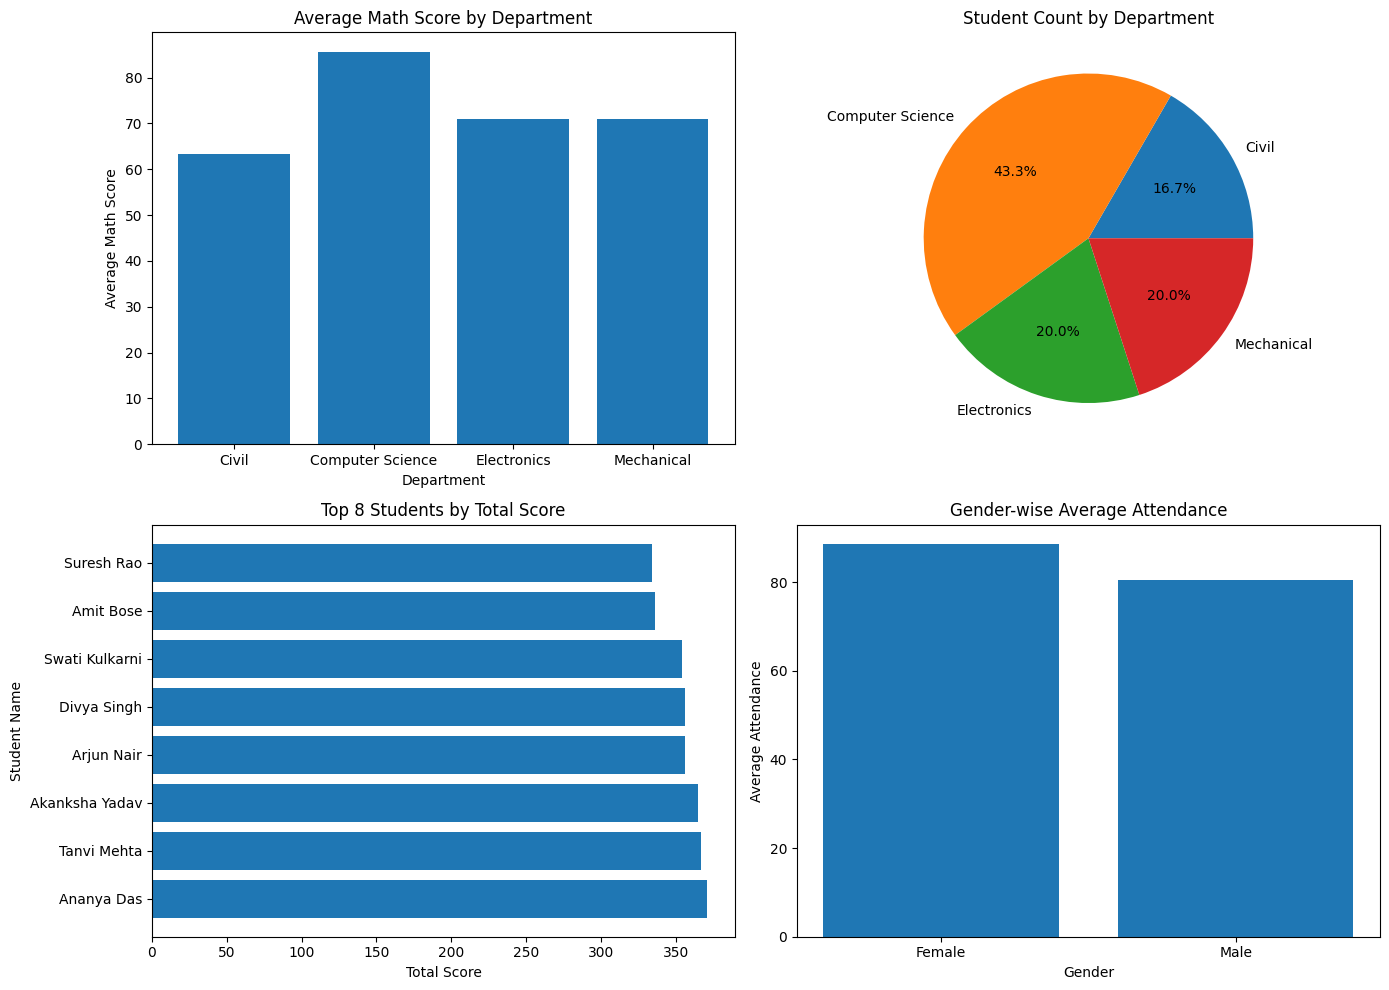

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# ── Panel 1 (top-left): Avg Math by Department - BAR Chart ──

ax[0,0].bar(panel1_data['department'],
            panel1_data['avg_math_score'])

ax[0,0].set_title("Average Math Score by Department")
ax[0,0].set_xlabel("Department")
ax[0,0].set_ylabel("Average Math Score")

# ── Panel 2 (top-right): Student Count Pie Chart ──

ax[0,1].pie(panel2_data['student_count'],
            labels=panel2_data['department'],
            autopct='%1.1f%%')

ax[0,1].set_title("Student Count by Department")

# ── Panel 3 (bottom-left): Top 8 Students Horizontal Bar ──

ax[1,0].barh(panel3_data['name'],
             panel3_data['total_score'])

ax[1,0].set_title("Top 8 Students by Total Score")
ax[1,0].set_xlabel("Total Score")
ax[1,0].set_ylabel("Student Name")

# ── Panel 4 (bottom-right): Gender Avg Attendance Bar ──

ax[1,1].bar(panel4_data['gender'],
            panel4_data['avg_attendance'])

ax[1,1].set_title("Gender-wise Average Attendance")
ax[1,1].set_xlabel("Gender")
ax[1,1].set_ylabel("Average Attendance")

plt.tight_layout()

plt.show()

In [17]:
query = """
SELECT AVG(programming_score) AS avg_programming_score
FROM students
WHERE gender = 'Female'
"""

result = pd.read_sql_query(query, conn)

print(result)

   avg_programming_score
0                   70.2


In [18]:
query = """
SELECT *
FROM students
WHERE math_score > 80
"""

result = pd.read_sql_query(query, conn)

print(result)

    student_id            name  age  gender        department  semester  \
0         1001    Aarav Sharma   19    Male  Computer Science         2   
1         1005      Arjun Nair   19    Male  Computer Science         2   
2         1008     Divya Singh   19  Female  Computer Science         2   
3         1010      Ananya Das   19  Female  Computer Science         2   
4         1013      Suresh Rao   21    Male  Computer Science         2   
5         1016    Ritu Agarwal   20  Female       Electronics         2   
6         1018  Swati Kulkarni   19  Female  Computer Science         2   
7         1022     Tanvi Mehta   19  Female  Computer Science         2   
8         1025       Amit Bose   19    Male  Computer Science         2   
9         1027   Gaurav Shukla   21    Male  Computer Science         2   
10        1030  Akanksha Yadav   19  Female  Computer Science         2   

    math_score  science_score  english_score  programming_score  \
0           85             78   

In [19]:
query = """
SELECT department,
AVG(math_score) AS avg_math
FROM students
GROUP BY department
HAVING AVG(math_score) > 80
"""

result = pd.read_sql_query(query, conn)

print(result)

         department   avg_math
0  Computer Science  85.615385


In [20]:
query = """
SELECT department,
AVG(attendance_percentage) AS avg_attendance
FROM students
GROUP BY department
HAVING AVG(attendance_percentage) > 85
"""

result = pd.read_sql_query(query, conn)

print(result)

         department  avg_attendance
0  Computer Science       90.692308


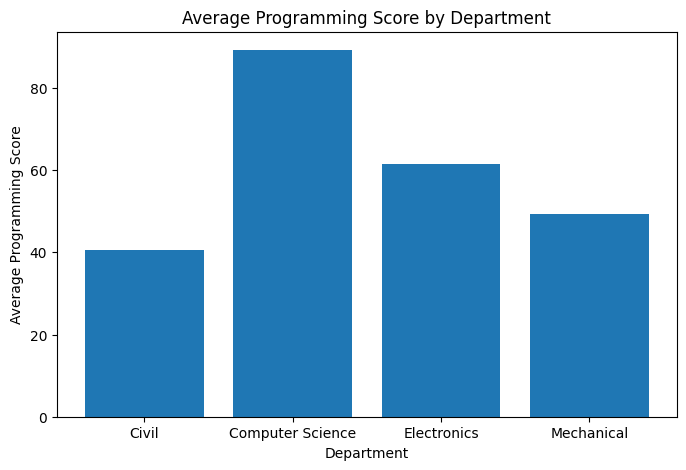

In [21]:
query = """
SELECT department,
AVG(programming_score) AS avg_programming_score
FROM students
GROUP BY department
"""

chart_data = pd.read_sql_query(query, conn)

plt.figure(figsize=(8,5))

plt.bar(chart_data['department'],
        chart_data['avg_programming_score'])

plt.title("Average Programming Score by Department")
plt.xlabel("Department")
plt.ylabel("Average Programming Score")

plt.show()

In [27]:
conn = sqlite3.connect("student.db")

department_data = {
    'department': ['Computer Science', 'ECE', 'IT', 'Mechical'],
    'hod_name': ['Arun Kumar', 'Priya Devi', 'Karthik', 'Suresh']
}

dept_df = pd.DataFrame(department_data)

dept_df.to_sql("department_info", conn, if_exists='replace', index=False)

print("Second table created successfully!")

Second table created successfully!


In [30]:
import pandas as pd
import sqlite3

# Connect SQLite Database
conn = sqlite3.connect("student.db")

# Read CSV File
df = pd.read_csv("student_performance.csv")

# Store DataFrame into SQLite Table
df.to_sql("students", conn, if_exists='replace', index=False)

print("Students table created successfully!")

Students table created successfully!


In [32]:
department_data = {
    'department': ['Computer Science', 'ECE', 'IT', 'MECH'],
    'hod_name': ['Arun Kumar', 'Priya Devi', 'Karthik', 'Suresh']
}

dept_df = pd.DataFrame(department_data)

dept_df.to_sql("department_info", conn,
               if_exists='replace',
               index=False)

print("Department table created!")

Department table created!


In [33]:
query = """
SELECT students.name,
students.department,
department_info.hod_name
FROM students
INNER JOIN department_info
ON students.department = department_info.department
"""

result = pd.read_sql_query(query, conn)

print(result)

              name        department    hod_name
0     Aarav Sharma  Computer Science  Arun Kumar
1      Priya Patel  Computer Science  Arun Kumar
2       Arjun Nair  Computer Science  Arun Kumar
3      Divya Singh  Computer Science  Arun Kumar
4       Ananya Das  Computer Science  Arun Kumar
5       Suresh Rao  Computer Science  Arun Kumar
6      Ajay Tiwari  Computer Science  Arun Kumar
7   Swati Kulkarni  Computer Science  Arun Kumar
8     Nisha Kapoor  Computer Science  Arun Kumar
9      Tanvi Mehta  Computer Science  Arun Kumar
10       Amit Bose  Computer Science  Arun Kumar
11   Gaurav Shukla  Computer Science  Arun Kumar
12  Akanksha Yadav  Computer Science  Arun Kumar


In [34]:
query = """
SELECT students.name,
students.department,
department_info.hod_name
FROM students
LEFT JOIN department_info
ON students.department = department_info.department
"""

result = pd.read_sql_query(query, conn)

print(result)

              name        department    hod_name
0     Aarav Sharma  Computer Science  Arun Kumar
1      Priya Patel  Computer Science  Arun Kumar
2      Rohit Verma       Electronics        None
3      Sneha Reddy        Mechanical        None
4       Arjun Nair  Computer Science  Arun Kumar
5      Meera Joshi       Electronics        None
6      Kiran Kumar             Civil        None
7      Divya Singh  Computer Science  Arun Kumar
8     Rahul Mishra        Mechanical        None
9       Ananya Das  Computer Science  Arun Kumar
10     Vikram Iyer       Electronics        None
11     Pooja Gupta             Civil        None
12      Suresh Rao  Computer Science  Arun Kumar
13   Kavya Nambiar        Mechanical        None
14     Ajay Tiwari  Computer Science  Arun Kumar
15    Ritu Agarwal       Electronics        None
16    Manoj Pandey             Civil        None
17  Swati Kulkarni  Computer Science  Arun Kumar
18  Deepak Chauhan        Mechanical        None
19    Nisha Kapoor  

In [35]:
query = """
SELECT students.name,
department_info.department,
department_info.hod_name
FROM department_info
LEFT JOIN students
ON students.department = department_info.department
"""

result = pd.read_sql_query(query, conn)

print(result)

              name        department    hod_name
0     Aarav Sharma  Computer Science  Arun Kumar
1      Ajay Tiwari  Computer Science  Arun Kumar
2   Akanksha Yadav  Computer Science  Arun Kumar
3        Amit Bose  Computer Science  Arun Kumar
4       Ananya Das  Computer Science  Arun Kumar
5       Arjun Nair  Computer Science  Arun Kumar
6      Divya Singh  Computer Science  Arun Kumar
7    Gaurav Shukla  Computer Science  Arun Kumar
8     Nisha Kapoor  Computer Science  Arun Kumar
9      Priya Patel  Computer Science  Arun Kumar
10      Suresh Rao  Computer Science  Arun Kumar
11  Swati Kulkarni  Computer Science  Arun Kumar
12     Tanvi Mehta  Computer Science  Arun Kumar
13            None               ECE  Priya Devi
14            None                IT     Karthik
15            None              MECH      Suresh


In [36]:
query = """
SELECT students.name,
students.department,
department_info.hod_name
FROM students
LEFT JOIN department_info
ON students.department = department_info.department

UNION

SELECT students.name,
department_info.department,
department_info.hod_name
FROM department_info
LEFT JOIN students
ON students.department = department_info.department
"""

result = pd.read_sql_query(query, conn)

print(result)

              name        department    hod_name
0             None               ECE  Priya Devi
1             None                IT     Karthik
2             None              MECH      Suresh
3     Aarav Sharma  Computer Science  Arun Kumar
4      Ajay Tiwari  Computer Science  Arun Kumar
5   Akanksha Yadav  Computer Science  Arun Kumar
6        Amit Bose  Computer Science  Arun Kumar
7       Ananya Das  Computer Science  Arun Kumar
8       Arjun Nair  Computer Science  Arun Kumar
9   Deepak Chauhan        Mechanical        None
10     Divya Singh  Computer Science  Arun Kumar
11   Gaurav Shukla  Computer Science  Arun Kumar
12   Harish Pillai       Electronics        None
13   Kavya Nambiar        Mechanical        None
14     Kiran Kumar             Civil        None
15    Manoj Pandey             Civil        None
16     Meera Joshi       Electronics        None
17    Nisha Kapoor  Computer Science  Arun Kumar
18      Nitin Jain        Mechanical        None
19     Pooja Gupta  